In [71]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np



In [50]:
#load data
funding = pd.read_csv(
    "C:/Users/liane/Dropbox/liane/PhD/Data_science_course/visualization/02_activities/assignments/assignment 3/research_funding_2024_25.csv",
    encoding="cp1252"
)

In [42]:
funding["City"].value_counts().head(1000)

City
Toronto             121
Ottawa               44
Waterloo             41
Kingston             30
Guelph               27
Hamilton             24
London               20
Windsor              10
Sault Ste. Marie      4
St. Catharines        3
Peterborough          2
Sarnia                2
Oshawa                2
Sudbury               1
Barrie                1
Name: count, dtype: int64

In [75]:
#quick check
funding.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 29 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Program                                          332 non-null    object 
 1   Round                                            332 non-null    object 
 2   Project Number                                   332 non-null    object 
 3   Project Title                                    332 non-null    object 
 4   Project Description                              332 non-null    object 
 5   Field of Research (FOR) - Level 1 Division Code  332 non-null    object 
 6   FOR - Level 1 Division Title                     332 non-null    object 
 7   FOR - Level 2 Group Code                         332 non-null    object 
 8   FOR - Level 2 Group Title                        332 non-null    object 
 9   FOR - Level 3 Class Code        

In [51]:
#import geo data
# Load Ontario municipal boundaries
ontario_map = gpd.read_file(
    "C:/Users/liane/Dropbox/liane/PhD/Data_science_course/visualization/02_activities/assignments/assignment 3/Municipal_Boundary_-_Lower_and_Single_Tier.geojson"
)


In [45]:
ontario_map.columns

Index(['OGF_ID', 'MUNICIPAL_TYPE', 'MUNICIPAL_TYPE_FR', 'MUNICIPAL_NAME',
       'MUNICIPAL_NAME_FR', 'MUNID', 'MAH_CODE', 'MUNICIPAL_AREA_EXTENT_TYPE',
       'MUNICIPAL_AREA_EXTENT_TYPE_FR', 'ASSESSMENT_CODE',
       'MUNICIPAL_NAME_PREFIX', 'MUNICIPAL_NAME_PREFIX_FR',
       'MUNICIPAL_NAME_SHORTFORM', 'MUNICIPAL_NAME_SHORTFORM_FR',
       'UPPER_TIER_ASSESSMENT_CODE', 'UPPER_TIER_MUNICIPALITY',
       'UPPER_TIER_MUNICIPALITY_FR', 'EFFECTIVE_DATETIME', 'SYSTEM_DATETIME',
       'OBJECTID', 'SHAPEAREA', 'SHAPELEN', 'geometry'],
      dtype='object')

In [77]:
ontario_map["MUNICIPAL_NAME"].value_counts().head(1000)


MUNICIPAL_NAME
TOWNSHIP OF GEORGIAN BLUFFS     3
MUNICIPALITY OF CHATHAM-KENT    3
TOWN OF DEEP RIVER              3
TOWNSHIP OF PAPINEAU-CAMERON    3
TOWNSHIP OF ST. CLAIR           3
                               ..
TOWNSHIP OF ENNISKILLEN         1
TOWNSHIP OF MULMUR              1
TOWNSHIP OF MAPLETON            1
TOWNSHIP OF LANARK HIGHLANDS    1
CITY OF KENORA                  1
Name: count, Length: 414, dtype: int64

In [52]:
# Remove leading/trailing spaces and normalize multiple spaces to single
ontario_map["MUNICIPAL_NAME"] = ontario_map["MUNICIPAL_NAME"].str.strip().str.replace(r'\s+', ' ', regex=True)

# replacements
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF BARRIE", "MUNICIPAL_NAME"] = "Barrie"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF GUELPH", "MUNICIPAL_NAME"] = "Guelph"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF HAMILTON", "MUNICIPAL_NAME"] = "Hamilton"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF KINGSTON", "MUNICIPAL_NAME"] = "Kingston"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF LONDON", "MUNICIPAL_NAME"] = "London"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF OSHAWA", "MUNICIPAL_NAME"] = "Oshawa"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF OTTAWA", "MUNICIPAL_NAME"] = "Ottawa"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF PETERBOROUGH", "MUNICIPAL_NAME"] = "Peterborough"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF SARNIA", "MUNICIPAL_NAME"] = "Sarnia"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF SAULT STE. MARIE", "MUNICIPAL_NAME"] = "Sault Ste. Marie"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF ST. CATHARINES", "MUNICIPAL_NAME"] = "St. Catharines"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF GREATER SUDBURY", "MUNICIPAL_NAME"] = "Sudbury"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF TORONTO", "MUNICIPAL_NAME"] = "Toronto"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF WATERLOO", "MUNICIPAL_NAME"] = "Waterloo"
ontario_map.loc[ontario_map["MUNICIPAL_NAME"] == "CITY OF WINDSOR", "MUNICIPAL_NAME"] = "Windsor"



In [5]:
#check if they remain
old_names = [
    "CITY OF BARRIE",
    "CITY OF GUELPH",
    "CITY OF HAMILTON",
    "CITY OF KINGSTON",
    "CITY OF LONDON",
    "CITY OF OSHAWA",
    "CITY OF OTTAWA",
    "CITY OF PETERBOROUGH",
    "CITY OF SARNIA",
    "CITY OF SAULT STE. MARIE",
    "CITY OF ST. CATHARINES",        
    "CITY OF GREATER SUDBURY",       
    "CITY OF TORONTO",
    "CITY OF WATERLOO",
    "CITY OF WINDSOR"
]
any_old_exists = ontario_map["MUNICIPAL_NAME"].isin(old_names).any()
print("Any old names left?:", any_old_exists)

Any old names left?: False


In [6]:
#check they changed in ontario maps
new_names = [
    "Barrie", "Guelph", "Hamilton", "Kingston", "London", "Oshawa", 
    "Ottawa", "Peterborough", "Sarnia", "Sault Ste. Marie", 
    "St. Catharines","Sudbury","Toronto","Waterloo","Windsor"
]

existing_new_names = ontario_map["MUNICIPAL_NAME"].isin(new_names)
print("New names present:", ontario_map.loc[existing_new_names, "MUNICIPAL_NAME"].unique())

New names present: ['Ottawa' 'Kingston' 'Sarnia' 'St. Catharines' 'Waterloo' 'Peterborough'
 'Sault Ste. Marie' 'Oshawa' 'Sudbury' 'Hamilton' 'Toronto' 'Windsor'
 'London' 'Barrie' 'Guelph']


In [7]:
# check they match in funding
cities_to_check = [
    "Barrie", "Guelph", "Hamilton", "Kingston", "London", "Oshawa", 
    "Ottawa", "Peterborough", "Sarnia", "Sault Ste. Marie", 
    "St. Catharines","Sudbury","Toronto","Waterloo","Windsor"
]

# Check which of these are in funding['City']
existing_in_funding = [city for city in cities_to_check if city in funding['City'].values]

# Check which are missing
missing_in_funding = [city for city in cities_to_check if city not in funding['City'].values]

print("Cities present in funding:", existing_in_funding)
print("Cities NOT in funding:", missing_in_funding)

Cities present in funding: ['Barrie', 'Guelph', 'Hamilton', 'Kingston', 'London', 'Oshawa', 'Ottawa', 'Peterborough', 'Sarnia', 'Sault Ste. Marie', 'St. Catharines', 'Sudbury', 'Toronto', 'Waterloo', 'Windsor']
Cities NOT in funding: []


In [8]:
# Cities in funding not matching the map
set(funding["City"]) - set(ontario_map["MUNICIPAL_NAME"])

set()

In [53]:
# Make one row per city 
funding_city = (
    funding
    .groupby("City", as_index=False)
    .agg({
        "Ontario Commitment": "sum",
        "population": "first" 
    })
)
# Each city should appear once
assert funding_city["City"].is_unique

# No missing population
funding_city[funding_city["population"].isna()]

,City,Ontario Commitment,population


In [54]:
#calculate funding per capita
funding_city["per_capita_funding"] = (
    funding_city["Ontario Commitment"] / funding_city["population"]
)

In [55]:
# merge cities in ontario_maps
ontario_map_city = (
    ontario_map
    .dissolve(by="MUNICIPAL_NAME", as_index=False)
)


In [ ]:
# merge ontario maps file with the funding file
city_map = ontario_map_city.merge(
    funding_city,
    left_on="MUNICIPAL_NAME",
    right_on="City",
    how="left"
)


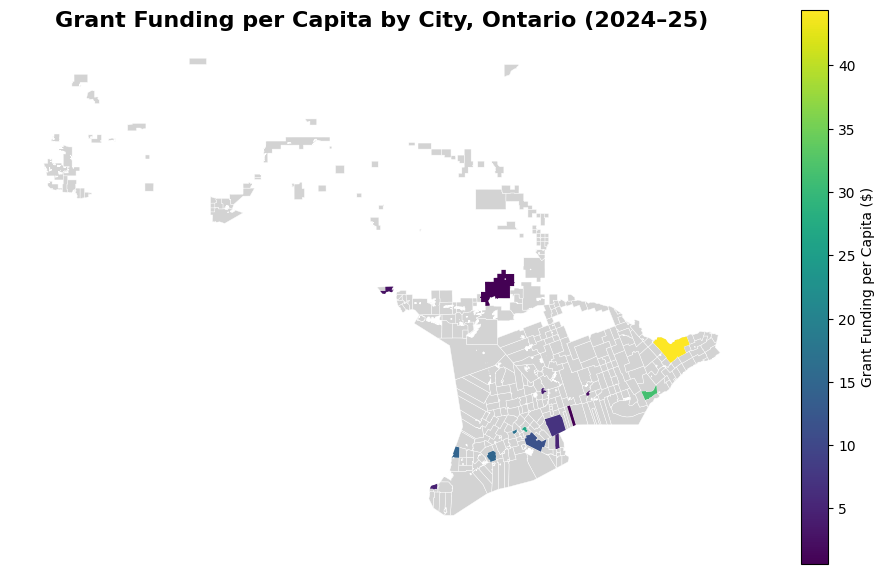

In [ ]:
# plot heatmap without legend
has_data = city_map["per_capita_funding"].notna()

fig, ax = plt.subplots(figsize=(12, 12))

# Base map (all municipalities)
city_map.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3
)

# Funding overlay
city_map[has_data].plot(
    ax=ax,
    column="per_capita_funding",
    cmap="viridis",
    legend=True,
    legend_kwds={
        "label": "Grant Funding per Capita ($)",
        "shrink": 0.6
    }
)

ax.set_title(
    "Grant Funding per Capita by City, Ontario (2024–25)",
    fontsize=16,
    fontweight="bold"
)
ax.axis("off")

plt.show()


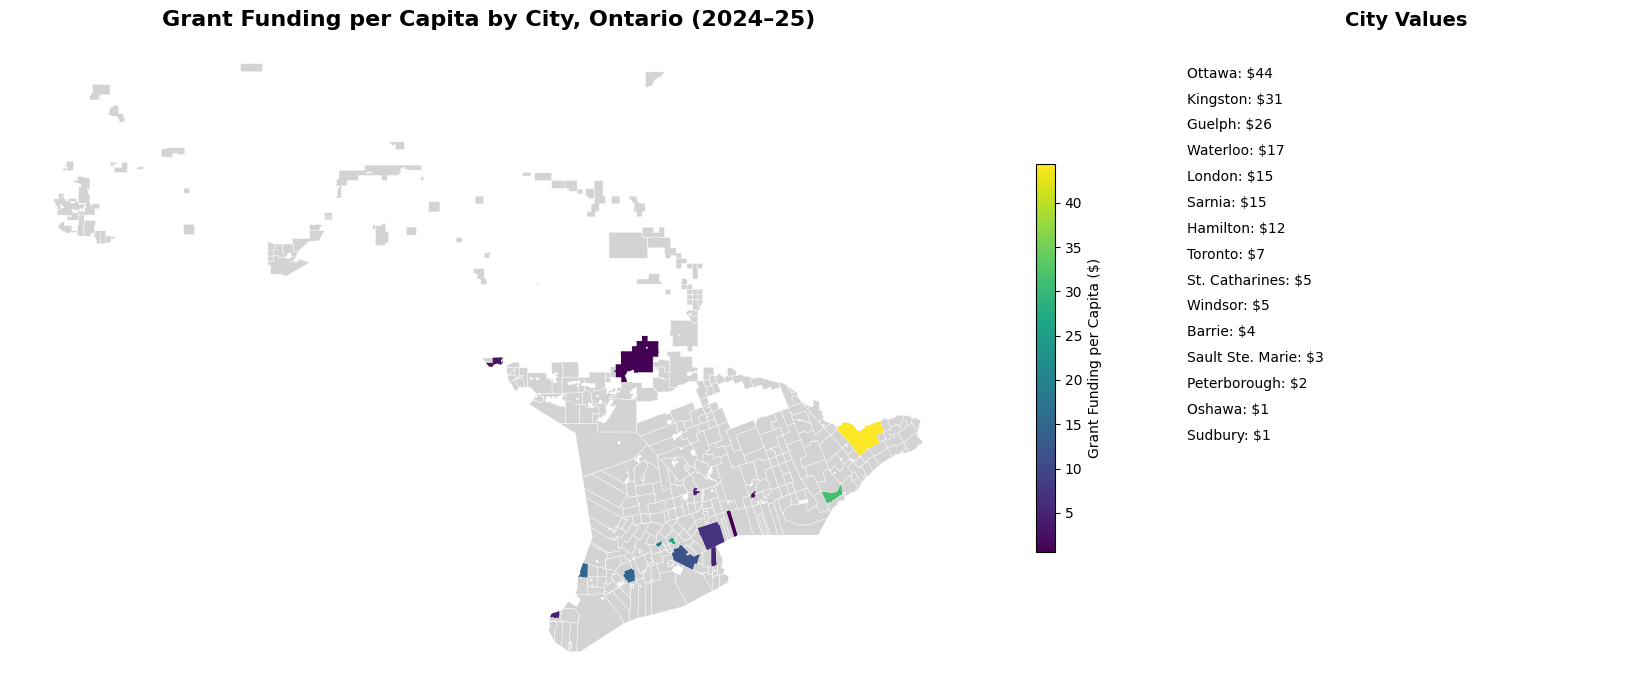

In [67]:
#add legend
# Identify cities with data
has_data = city_map["per_capita_funding"].notna()

# Prepare table for legend (sorted)
legend_data = (
    city_map[has_data][["MUNICIPAL_NAME", "per_capita_funding"]]
    .sort_values("per_capita_funding", ascending=False)
)

# Create side-by-side layout
fig, (ax_map, ax_legend) = plt.subplots(
    1, 2,
    figsize=(18, 7),
    gridspec_kw={"width_ratios": [3, 1]}
)

# ---- MAP ----
city_map.plot(
    ax=ax_map,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3
)

city_map[has_data].plot(
    ax=ax_map,
    column="per_capita_funding",
    cmap="viridis",
    legend=True,
    legend_kwds={
        "label": "Grant Funding per Capita ($)",
        "shrink": 0.6
    }
)

ax_map.set_title(
    "Grant Funding per Capita by City, Ontario (2024–25)",
    fontsize=16,
    fontweight="bold"
)
ax_map.axis("off")

# ---- LEGEND PANEL ----
ax_legend.axis("off")
ax_legend.set_title("City Values", fontsize=14, fontweight="bold")

# position
y = 0.95
step = 0.04  
for _, row in legend_data.iterrows():
    ax_legend.text(
        0.02, y,
        f"{row['MUNICIPAL_NAME']}: ${row['per_capita_funding']:,.0f}",
        fontsize=10,
        va="top"
    )
    y -= step

plt.tight_layout()
plt.show()
